# Temporal Ensembling for B-Spline Trajectories

This notebook demonstrates the temporal ensembling technique from the ACT paper applied to B-spline tokenized trajectories.

**Key idea**: Query the policy more frequently than the action chunk duration, creating overlapping predictions that are combined with exponential weighting to produce smoother actions.

**Setup**:
- Action chunk duration: 0.8s
- Query frequency: 10 Hz (every 0.1s)
- Up to 8 overlapping predictions at any time
- Weights: $w_i = \exp(-m \cdot i)$ where $i$ is the age of the prediction

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from bspline_tokenizer import BSplineTokenizer, BSplineTemporalEnsemble

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

## 1. Understanding Temporal Ensembling

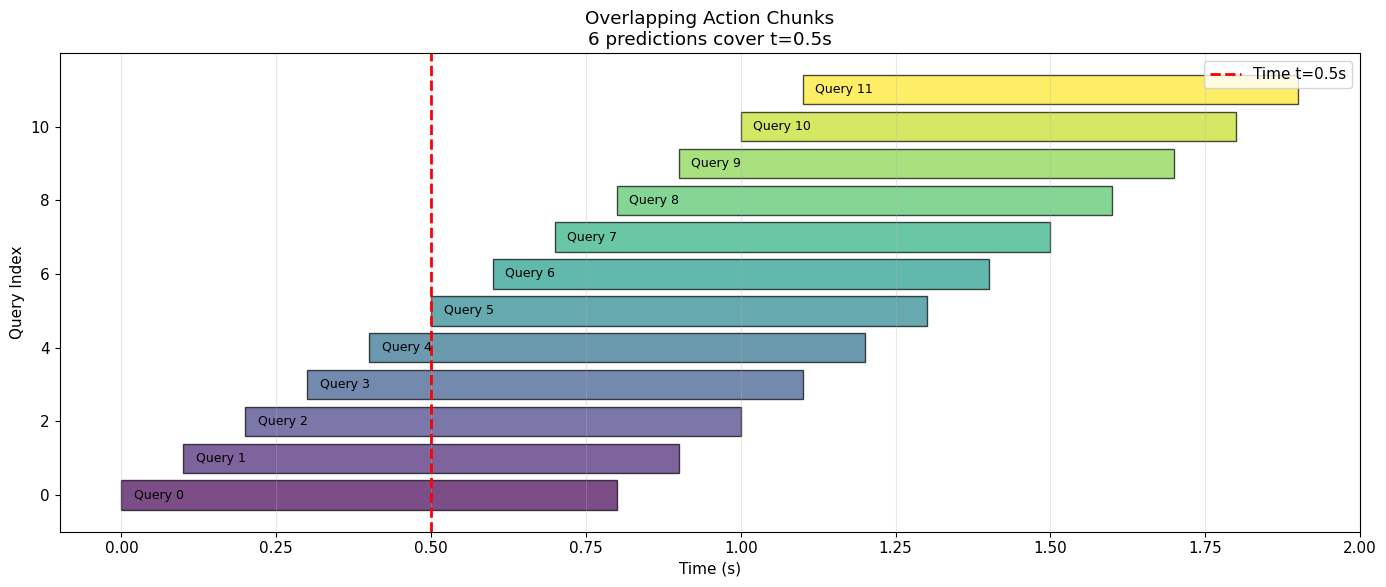

Chunk duration: 0.8s
Query period: 0.1s (10 Hz)
Max overlapping predictions: 8


In [3]:
# Visualize the overlapping predictions concept
chunk_duration = 0.8  # seconds
query_period = 0.1    # seconds (10 Hz)

fig, ax = plt.subplots(figsize=(14, 6))

n_queries = 12
colors = plt.cm.viridis(np.linspace(0, 1, n_queries))

for i in range(n_queries):
    query_time = i * query_period
    end_time = query_time + chunk_duration
    
    # Draw chunk as a rectangle
    ax.barh(i, chunk_duration, left=query_time, height=0.8, 
            color=colors[i], alpha=0.7, edgecolor='black')
    ax.text(query_time + 0.02, i, f'Query {i}', va='center', fontsize=9)

# Mark a specific time point
target_time = 0.5
ax.axvline(target_time, color='red', linewidth=2, linestyle='--', label=f'Time t={target_time}s')

# Count overlapping predictions at target_time
n_overlap = sum(1 for i in range(n_queries) 
                if i * query_period <= target_time <= i * query_period + chunk_duration)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Query Index')
ax.set_title(f'Overlapping Action Chunks\n{n_overlap} predictions cover t={target_time}s')
ax.legend(loc='upper right')
ax.set_xlim(-0.1, 2.0)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"Chunk duration: {chunk_duration}s")
print(f"Query period: {query_period}s ({1/query_period:.0f} Hz)")
print(f"Max overlapping predictions: {int(np.ceil(chunk_duration / query_period))}")

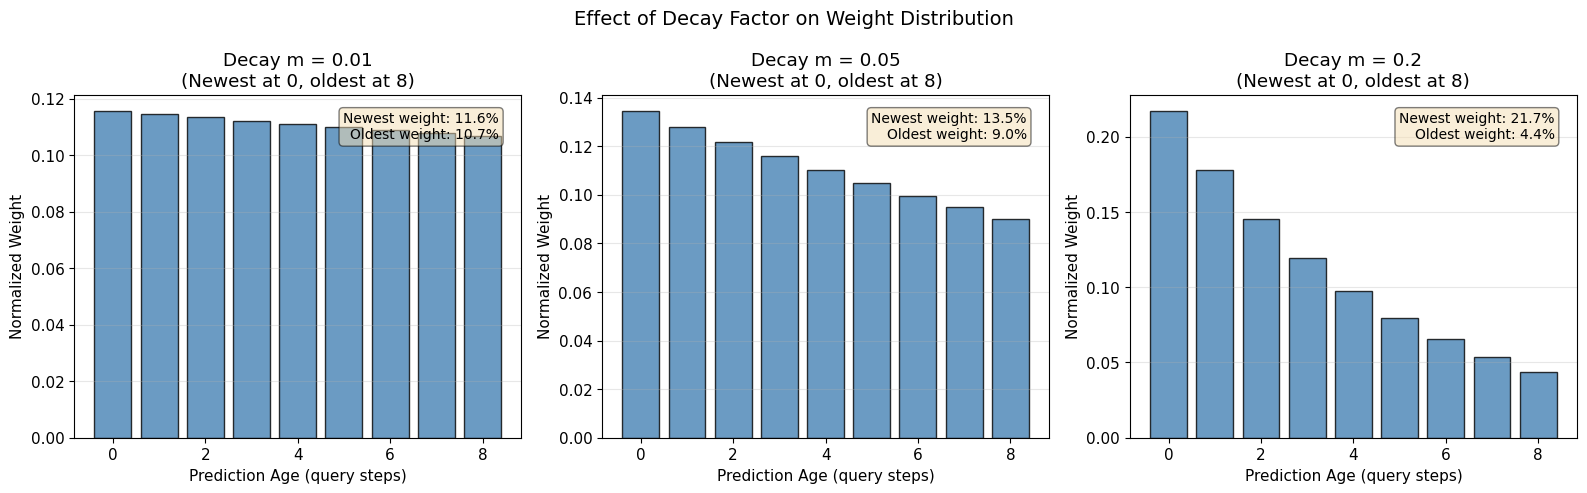

In [4]:
# Visualize exponential weighting
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

decay_values = [0.01, 0.05, 0.2]
max_age = 8
ages = np.arange(max_age + 1)

for ax, m in zip(axes, decay_values):
    weights = np.exp(-m * ages)
    weights_norm = weights / weights.sum()
    
    ax.bar(ages, weights_norm, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_xlabel('Prediction Age (query steps)')
    ax.set_ylabel('Normalized Weight')
    ax.set_title(f'Decay m = {m}\n(Newest at 0, oldest at {max_age})')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Annotate effective contributions
    ax.text(0.95, 0.95, f'Newest weight: {weights_norm[0]:.1%}\nOldest weight: {weights_norm[-1]:.1%}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Effect of Decay Factor on Weight Distribution', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Setup Tokenizer and Ensemble

In [5]:
# Create tokenizer for 7-DoF robot
tokenizer = BSplineTokenizer(
    n_dof=7,
    n_control_points=8,
    degree=4,
    bounds=(-1.5, 1.5),
    n_bins=256
)

# Create temporal ensemble
ensemble = BSplineTemporalEnsemble(
    tokenizer=tokenizer,
    chunk_duration=0.8,      # Each prediction covers 0.8 seconds
    query_frequency=10.0,    # Query policy at 10 Hz
    exp_weight_decay=0.05    # Moderate decay
)

print(ensemble)

BSplineTemporalEnsemble(
  chunk_duration=0.8s,
  query_frequency=10.0Hz,
  query_period=0.100s,
  exp_weight_decay=0.05,
  max_overlap=8,
  buffer_size=0/9,
  current_time=0.000s,
  n_dof=7
)


## 3. Simulate Noisy Policy Predictions

In [6]:
# Generate a long "ground truth" trajectory that the policy is trying to track
# This represents the actual motion happening over time (e.g., 5 seconds)
n_dof = 7
total_duration = 5.0  # 5 seconds of motion
t_global = np.linspace(0, total_duration, 500)

# Smooth ground truth trajectory over the full duration
ground_truth_full = np.zeros((500, n_dof))
for dof in range(n_dof):
    freq = 0.3 + dof * 0.05  # Slower frequencies for realistic motion
    phase = dof * np.pi / 4
    ground_truth_full[:, dof] = 0.5 * np.sin(2 * np.pi * freq * t_global + phase)

# Simulate policy predictions with noise
# Key insight: Each prediction covers chunk_duration (0.8s) starting from the current time
# The predictions should be correlated because they're predicting overlapping time windows

n_queries = 30
noise_std = 0.08  # Noise in policy predictions
chunk_duration = 0.8
query_period = 0.1  # 10 Hz

# Storage for results
all_raw_actions = []  # Without ensemble (just latest prediction at t=0 of that chunk)
all_ensembled_actions = []  # With ensemble
query_times = []
ground_truth_at_queries = []

t_chunk = np.linspace(0, 1, 50)  # Normalized time within a chunk

for i in range(n_queries):
    query_time = i * query_period
    
    # Get the ground truth for this chunk's time window [query_time, query_time + chunk_duration]
    chunk_start_idx = int(query_time / total_duration * 500)
    chunk_end_idx = int((query_time + chunk_duration) / total_duration * 500)
    chunk_end_idx = min(chunk_end_idx, 499)
    
    # Sample 50 points from the ground truth for this time window
    gt_indices = np.linspace(chunk_start_idx, chunk_end_idx, 50).astype(int)
    gt_chunk = ground_truth_full[gt_indices]
    
    # Add noise to simulate imperfect policy prediction
    noisy_trajectory = gt_chunk + np.random.randn(50, n_dof) * noise_std
    
    # Encode to tokens
    tokens = tokenizer.encode(t_chunk, noisy_trajectory)
    
    # Get raw action (without ensemble - just decode current prediction at t=0)
    raw_traj = tokenizer.decode(tokens)(0.0)  # Evaluate at t=0
    all_raw_actions.append(raw_traj)
    
    # Add to ensemble 
    # Note: add_prediction() advances internal time by query_period after storing
    # So we need to use time_offset=-query_period to get action at the query_time
    ensemble.add_prediction(tokens)
    ensembled_action = ensemble.get_action(time_offset=-ensemble.query_period)
    all_ensembled_actions.append(ensembled_action)
    
    query_times.append(query_time)
    
    # Store the actual ground truth at the query time for comparison
    gt_idx = int(query_time / total_duration * 499)
    ground_truth_at_queries.append(ground_truth_full[gt_idx])

all_raw_actions = np.array(all_raw_actions)
all_ensembled_actions = np.array(all_ensembled_actions)
query_times = np.array(query_times)
ground_truth_at_queries = np.array(ground_truth_at_queries)

print(f"Generated {n_queries} predictions")
print(f"Query times: {query_times[0]:.2f}s to {query_times[-1]:.2f}s")
print(f"Each chunk covers {chunk_duration}s, so predictions overlap significantly")

Generated 30 predictions
Query times: 0.00s to 2.90s
Each chunk covers 0.8s, so predictions overlap significantly


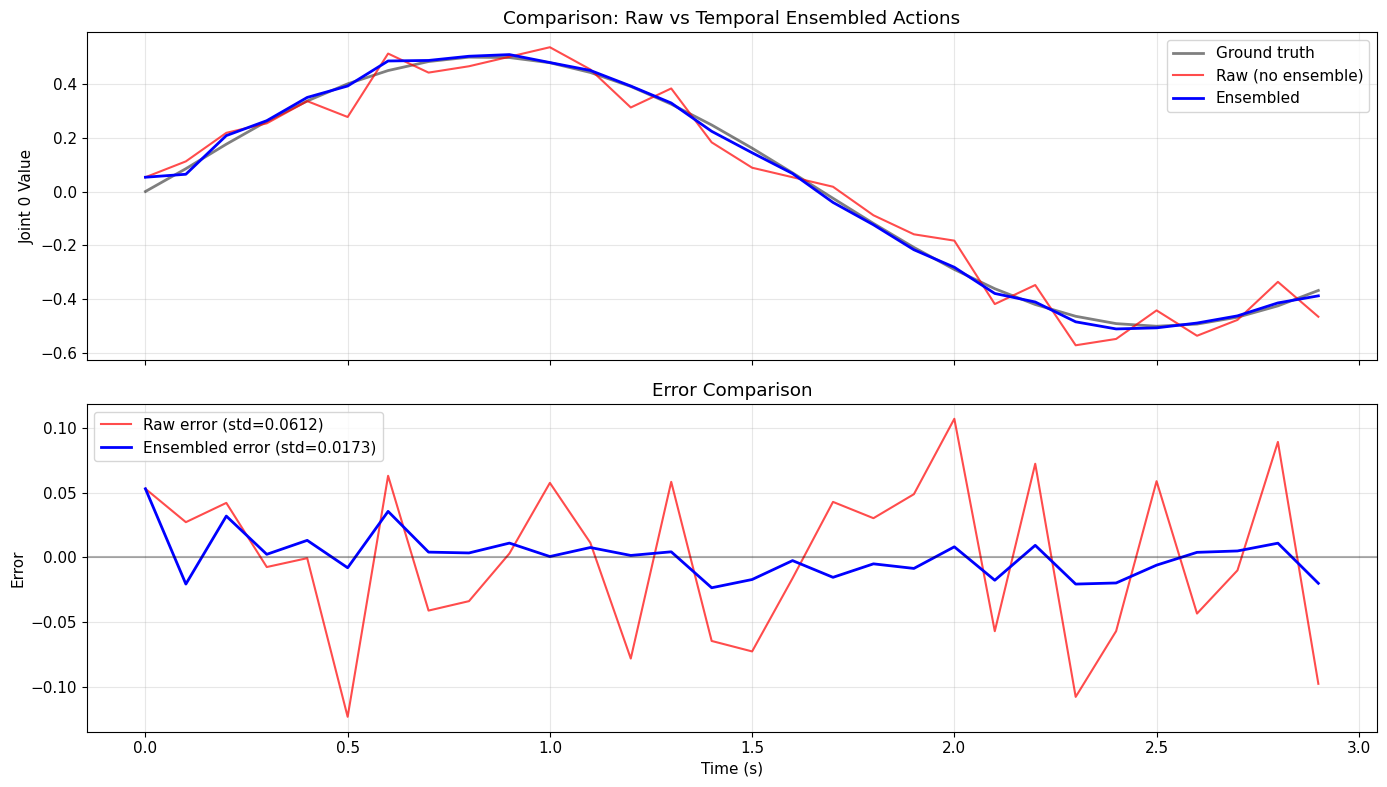


Error Statistics (Joint 0):
  Raw:       std=0.06124, max=0.12298
  Ensembled: std=0.01733, max=0.05294
  Improvement: 71.7% reduction in std


In [7]:
# Compare raw vs ensembled for one DoF
dof = 0

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Use the ground truth we stored at each query time
gt_at_queries = ground_truth_at_queries[:, dof]

# Top plot: trajectories
ax = axes[0]
ax.plot(query_times, gt_at_queries, 'k-', linewidth=2, alpha=0.5, label='Ground truth')
ax.plot(query_times, all_raw_actions[:, dof], 'r-', linewidth=1.5, alpha=0.7, label='Raw (no ensemble)')
ax.plot(query_times, all_ensembled_actions[:, dof], 'b-', linewidth=2, label='Ensembled')
ax.set_ylabel(f'Joint {dof} Value')
ax.set_title('Comparison: Raw vs Temporal Ensembled Actions')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom plot: errors
ax = axes[1]
raw_error = all_raw_actions[:, dof] - gt_at_queries
ensembled_error = all_ensembled_actions[:, dof] - gt_at_queries

ax.plot(query_times, raw_error, 'r-', linewidth=1.5, alpha=0.7, label=f'Raw error (std={np.std(raw_error):.4f})')
ax.plot(query_times, ensembled_error, 'b-', linewidth=2, label=f'Ensembled error (std={np.std(ensembled_error):.4f})')
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Error')
ax.set_title('Error Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nError Statistics (Joint {dof}):")
print(f"  Raw:       std={np.std(raw_error):.5f}, max={np.max(np.abs(raw_error)):.5f}")
print(f"  Ensembled: std={np.std(ensembled_error):.5f}, max={np.max(np.abs(ensembled_error)):.5f}")
print(f"  Improvement: {(1 - np.std(ensembled_error)/np.std(raw_error))*100:.1f}% reduction in std")

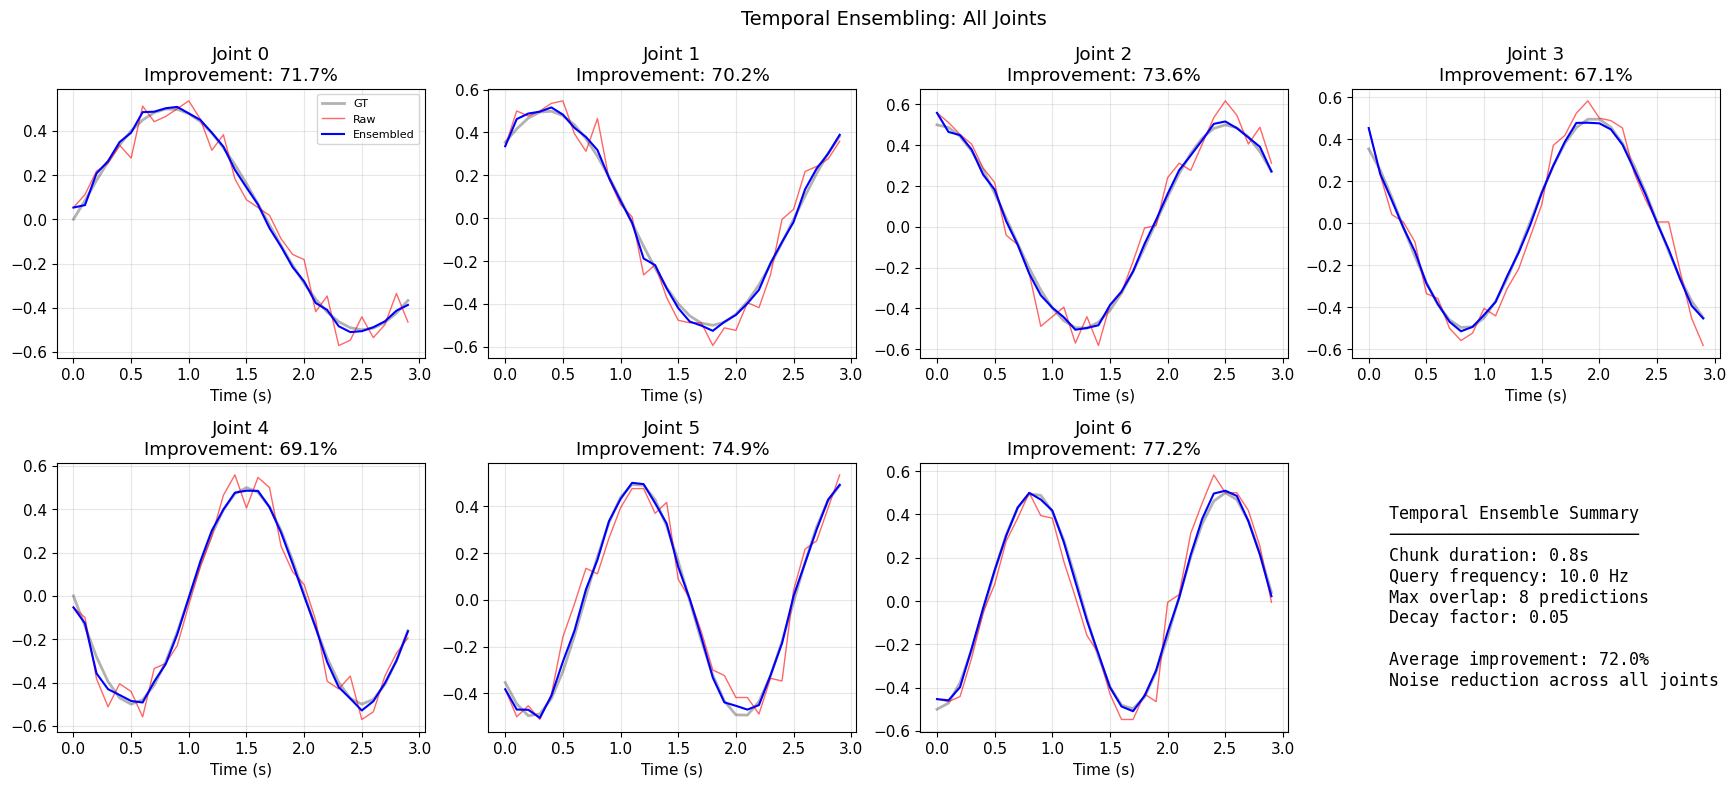

In [8]:
# Compare across all DoFs
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

improvements = []

for dof in range(n_dof):
    ax = axes[dof]
    
    gt = ground_truth_at_queries[:, dof]
    
    ax.plot(query_times, gt, 'k-', linewidth=2, alpha=0.3, label='GT')
    ax.plot(query_times, all_raw_actions[:, dof], 'r-', linewidth=1, alpha=0.6, label='Raw')
    ax.plot(query_times, all_ensembled_actions[:, dof], 'b-', linewidth=1.5, label='Ensembled')
    
    raw_std = np.std(all_raw_actions[:, dof] - gt)
    ens_std = np.std(all_ensembled_actions[:, dof] - gt)
    improvement = (1 - ens_std/raw_std) * 100
    improvements.append(improvement)
    
    ax.set_title(f'Joint {dof}\nImprovement: {improvement:.1f}%')
    ax.set_xlabel('Time (s)')
    ax.grid(True, alpha=0.3)
    if dof == 0:
        ax.legend(fontsize=8)

# Summary in last subplot
axes[7].axis('off')
summary = f"""Temporal Ensemble Summary
─────────────────────────
Chunk duration: {ensemble.chunk_duration}s
Query frequency: {ensemble.query_frequency} Hz
Max overlap: {ensemble.max_overlap} predictions
Decay factor: {ensemble.exp_weight_decay}

Average improvement: {np.mean(improvements):.1f}%
Noise reduction across all joints"""
axes[7].text(0.1, 0.5, summary, transform=axes[7].transAxes, fontsize=12,
             verticalalignment='center', fontfamily='monospace')

plt.suptitle('Temporal Ensembling: All Joints', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Effect of Decay Factor

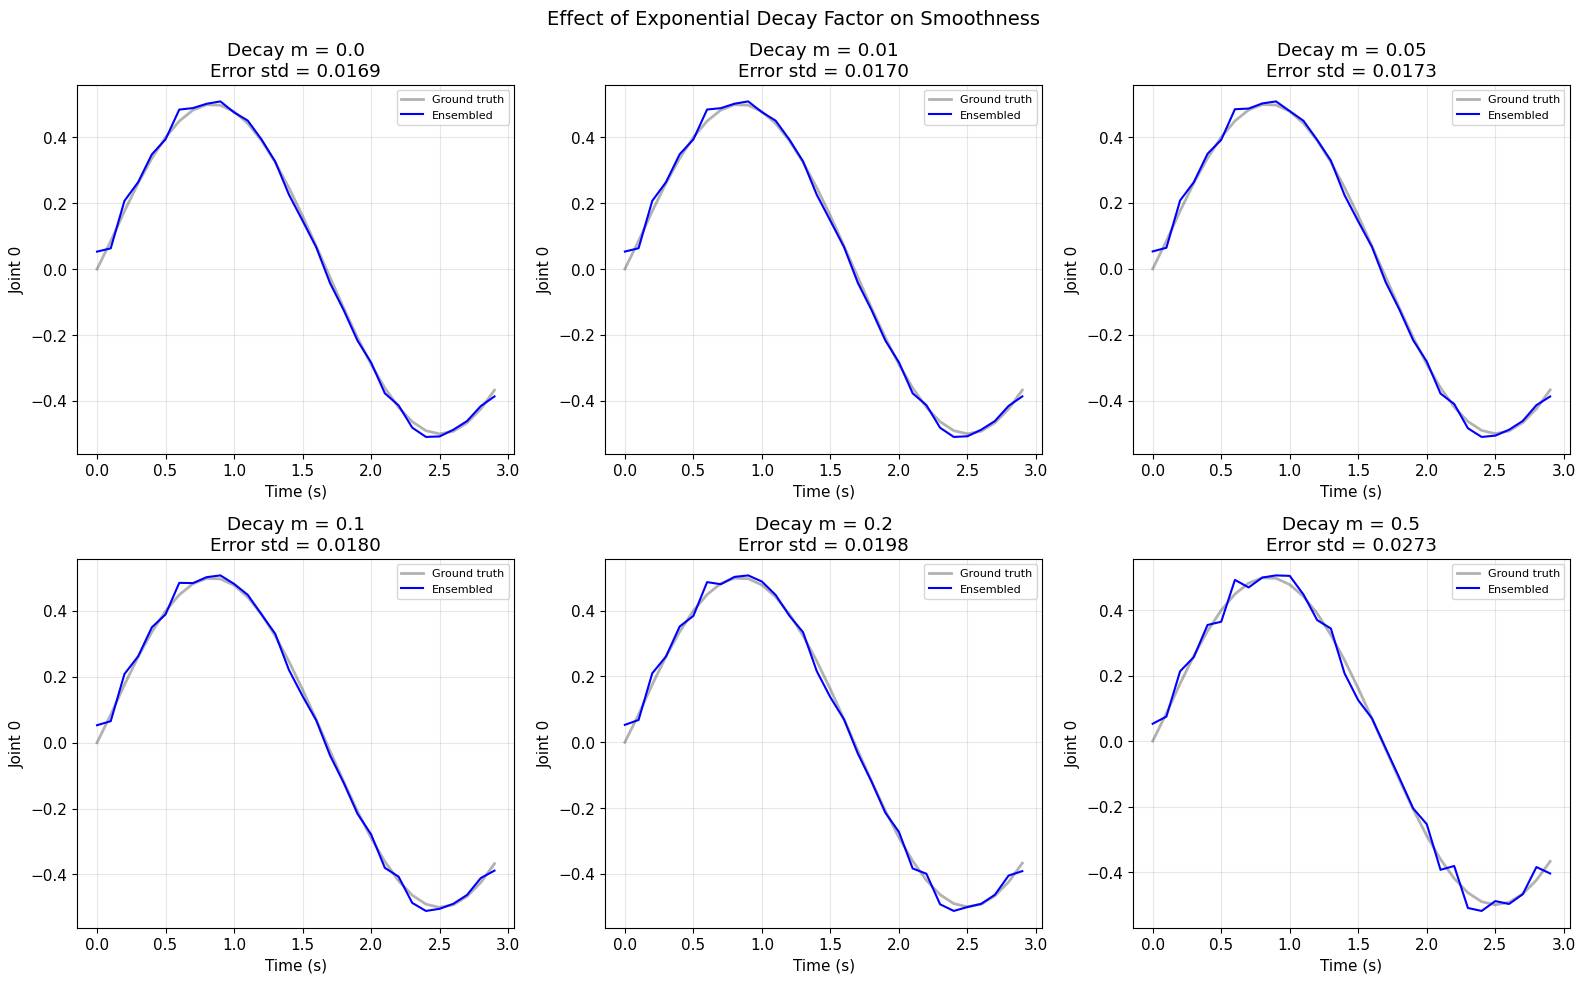

In [9]:
# Test different decay factors
decay_values = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

dof = 0
gt_at_queries = ground_truth_at_queries[:, dof]

for idx, decay in enumerate(decay_values):
    # Create new ensemble with this decay
    ens = BSplineTemporalEnsemble(
        tokenizer=tokenizer,
        chunk_duration=0.8,
        query_frequency=10.0,
        exp_weight_decay=decay
    )
    
    # Replay the same predictions with the same noise
    np.random.seed(42)  # Same noise as before
    actions = []
    
    for i in range(n_queries):
        query_time = i * query_period
        
        # Get the ground truth for this chunk's time window
        chunk_start_idx = int(query_time / total_duration * 500)
        chunk_end_idx = int((query_time + chunk_duration) / total_duration * 500)
        chunk_end_idx = min(chunk_end_idx, 499)
        
        gt_indices = np.linspace(chunk_start_idx, chunk_end_idx, 50).astype(int)
        gt_chunk = ground_truth_full[gt_indices]
        
        noisy_trajectory = gt_chunk + np.random.randn(50, n_dof) * noise_std
        tokens = tokenizer.encode(t_chunk, noisy_trajectory)
        ens.add_prediction(tokens)
        # Use negative offset to get action at actual query time
        actions.append(ens.get_action(time_offset=-ens.query_period))
    
    actions = np.array(actions)
    error_std = np.std(actions[:, dof] - gt_at_queries)
    
    ax = axes[idx]
    ax.plot(query_times, gt_at_queries, 'k-', linewidth=2, alpha=0.3, label='Ground truth')
    ax.plot(query_times, actions[:, dof], 'b-', linewidth=1.5, label='Ensembled')
    ax.set_title(f'Decay m = {decay}\nError std = {error_std:.4f}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(f'Joint {dof}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Effect of Exponential Decay Factor on Smoothness', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Visualize Ensemble State

In [10]:
# Show the current ensemble state
info = ensemble.get_ensemble_info()

print("Current Ensemble State:")
print(f"  Current time: {info['current_time']:.2f}s")
print(f"  Total queries: {info['query_count']}")
print(f"  Buffer size: {info['buffer_size']}")
print(f"  Overlapping predictions: {info['n_overlapping']} / {info['max_overlap']}")
print(f"  Prediction ages: {info['prediction_ages']}")
print(f"  Normalized weights: {[f'{w:.3f}' for w in info['normalized_weights']]}")

Current Ensemble State:
  Current time: 3.00s
  Total queries: 30
  Buffer size: 9
  Overlapping predictions: 7 / 8
  Prediction ages: [7.000000000000006, 6.000000000000005, 5.000000000000004, 4.0000000000000036, 3.0000000000000027, 2.0000000000000018, 1.0000000000000009]
  Normalized weights: ['0.122', '0.129', '0.135', '0.142', '0.149', '0.157', '0.165']


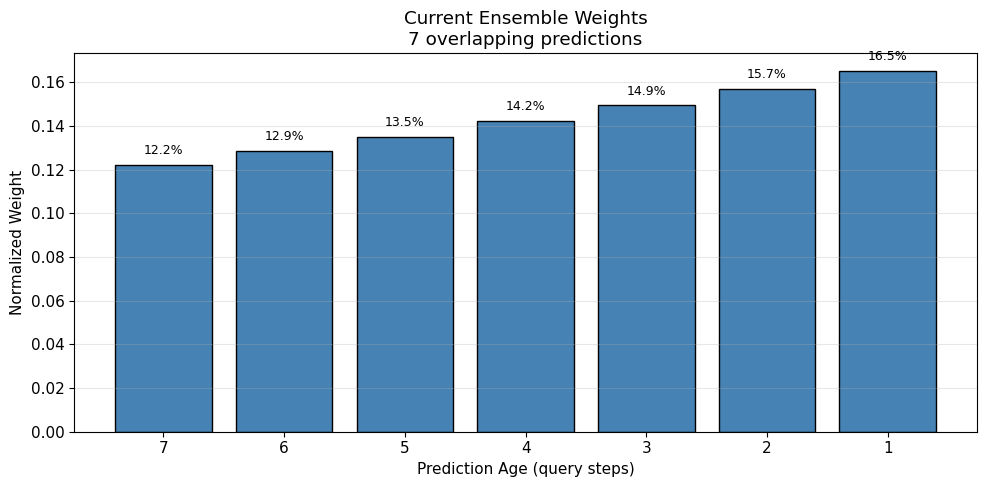

In [11]:
# Visualize the weights
fig, ax = plt.subplots(figsize=(10, 5))

ages = info['prediction_ages']
weights = info['normalized_weights']

bars = ax.bar(range(len(weights)), weights, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(weights)))
ax.set_xticklabels([f'{a:.0f}' for a in ages])
ax.set_xlabel('Prediction Age (query steps)')
ax.set_ylabel('Normalized Weight')
ax.set_title(f'Current Ensemble Weights\n{len(weights)} overlapping predictions')
ax.grid(True, alpha=0.3, axis='y')

# Annotate bars with percentages
for bar, w in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{w:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Get Future Trajectory

Future trajectory shape: (50, 7)
Time range: 2.80s to 3.70s
Valid coverage ends at: 3.70s


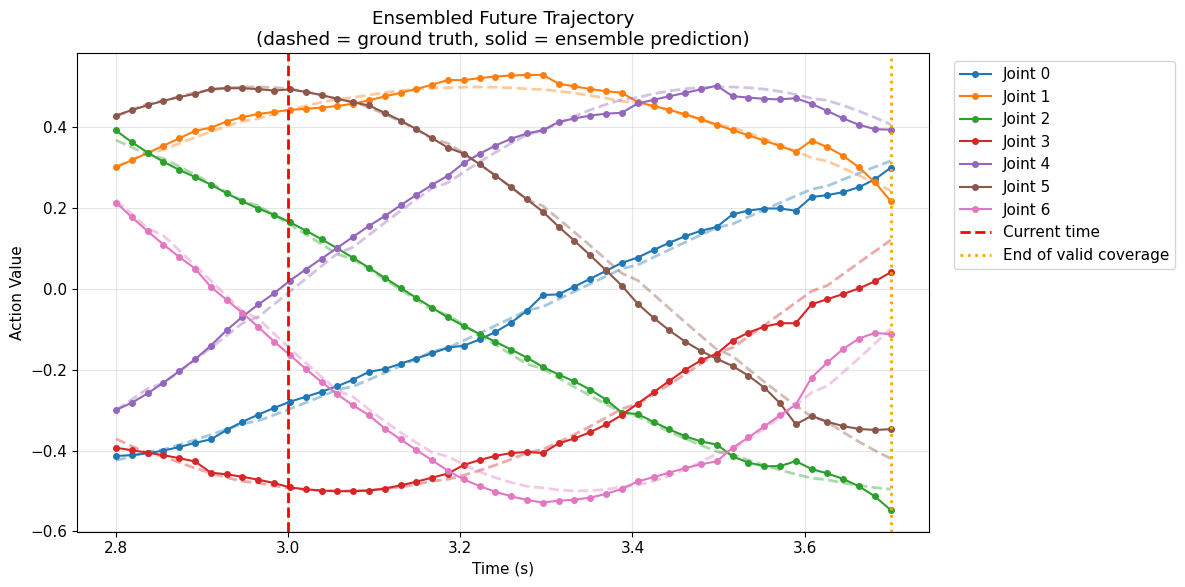

In [12]:
# Get ensembled trajectory for the remaining valid time window
# After the last prediction, we can only query up to chunk_duration into the future
# But since current_time is already advanced by one query_period after the last add_prediction(),
# the valid range is approximately [current_time - query_period, last_query_time + chunk_duration]

last_query_time = query_times[-1]  # 2.9s
max_valid_time = last_query_time + chunk_duration  # 2.9 + 0.8 = 3.7s
current_time = ensemble.current_time  # 3.0s (after 30 queries)

# Query from slightly before current_time to the end of valid coverage
start_time = current_time - 0.2  # Start a bit in the past to show context
end_time = max_valid_time

# Use linspace to ensure we include the endpoint
future_times = np.linspace(start_time, end_time, 50)

future_trajectory = []

for t in future_times:
    offset = t - current_time
    action = ensemble.get_action(time_offset=offset)
    future_trajectory.append(action)

future_trajectory = np.array(future_trajectory)

print(f"Future trajectory shape: {future_trajectory.shape}")
print(f"Time range: {future_times[0]:.2f}s to {future_times[-1]:.2f}s")
print(f"Valid coverage ends at: {max_valid_time:.2f}s")

# Also get the ground truth for comparison
gt_future = []
for t in future_times:
    gt_idx = int(t / total_duration * 499)
    gt_idx = min(gt_idx, 499)
    gt_future.append(ground_truth_full[gt_idx])
gt_future = np.array(gt_future)

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

for dof in range(n_dof):
    color = plt.cm.tab10(dof)
    ax.plot(future_times, gt_future[:, dof], '--', color=color, alpha=0.4, linewidth=2)
    ax.plot(future_times, future_trajectory[:, dof], '-o', color=color, markersize=4, label=f'Joint {dof}')

ax.axvline(current_time, color='red', linestyle='--', linewidth=2, label='Current time')
ax.axvline(max_valid_time, color='orange', linestyle=':', linewidth=2, label='End of valid coverage')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Action Value')
ax.set_title(f'Ensembled Future Trajectory\n(dashed = ground truth, solid = ensemble prediction)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

**Temporal Ensembling Benefits:**

1. **Smoother actions**: Averaging multiple predictions reduces noise and jitter
2. **Robust to outliers**: No single bad prediction can cause a large jump
3. **Tunable**: Decay factor controls the trade-off between smoothness and responsiveness

**Recommended Settings:**

| Parameter | Typical Value | Notes |
|-----------|--------------|-------|
| `chunk_duration` | 0.5 - 1.0s | Depends on your task horizon |
| `query_frequency` | 10-20 Hz | Higher = smoother but more compute |
| `exp_weight_decay` | 0.01 - 0.1 | Lower = smoother, higher = more responsive |

**Usage Pattern:**
```python
# In your control loop:
while running:
    # Get tokens from policy
    tokens = policy(observation)
    
    # Add to ensemble
    ensemble.add_prediction(tokens)
    
    # Get smoothed action
    action = ensemble.get_action()
    
    # Execute
    robot.execute(action)
```